<a href="https://colab.research.google.com/github/JoseRebollar95/ConnectaTel_Analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# Cantidad y proporción de nulos en USERS
print("--- Nulos en USERS ---")
print(users.isna().sum())
print("\nProporción (%):")
print(users.isna().mean() * 100)

--- Nulos en USERS ---
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción (%):
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
# Cantidad y proporción de nulos en USAGE
print("--- Nulos en USAGE ---")
print(usage.isna().sum())
print("\nProporción (%):")
print(usage.isna().mean() * 100)

--- Nulos en USAGE ---
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción (%):
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Resumen de Calidad de Datos
1. Dataset: users (Usuarios)
Columna city (11.7% nulos):

Diagnóstico: Rango de investigación (5-30%).

Acción: Imputar con "Unknown". No eliminamos porque perderíamos casi el 12% de la base de clientes para otros cálculos (como ingresos totales).

Columna churn_date (88.3% nulos):

Diagnóstico: Rango de ignorar (>80%).

Acción: Mantener como está. El nulo es informativo: indica que el cliente es activo. Solo el 11.7% ha cancelado el servicio.

2. Dataset: usage (Consumo)
Columna date (0.12% nulos):

Diagnóstico: Caso simple (<5%).

Acción: Eliminar estas 50 filas. Sin fecha no se puede asignar el consumo a un mes, y el impacto en el volumen total (40k filas) es nulo.

Columnas duration y length (45-55% nulos):

Diagnóstico: Nulos estructurales (Dataset híbrido).

Acción: Imputar con 0. Los nulos existen porque una fila es llamada (sin mensajes) o es mensaje (sin duración). Llenar con 0 permite sumar consumos sin errores matemáticos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# Resumen estadístico de las columnas numéricas en users
print("Resumen estadístico de 'users':")
print(users.describe())

Resumen estadístico de 'users':
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
user_id hace una suma del user id cuando es el numero de usuario.
- La columna `age` va de -999 a 79, por lo cual existen sentinels

In [ ]:
# 1. Explorar columnas numéricas (Resumen estadístico)
print("--- Resumen Estadístico 'usage': ")
print(usage[['id', 'user_id', 'duration', 'length']].describe())

# 2. Explorar columnas categóricas (Valores únicos)
print("\n--- Valores Únicos de 'usage': ")
print("Tipos de consumo (columna 'type'):", usage['type'].unique())

--- Resumen Estadístico 'usage': 
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000

--- Valores Únicos de 'usage': 
Tipos de consumo (columna 'type'): ['call' 'text']


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
  Siguen siendo la suma de los folios, cuando esa informacion serviria más para localización en lugar de valores numéricos.
- Las columnas duration y lenght son los valores que buscamos, nos ayudan a comprender el uso que los usuarios dan a su línea.

In [ ]:
# Definimos las columnas categóricas relevantes
columnas_user = ['city', 'plan']

# Exploración de valores únicos
print("--- Exploración Categórica: USERS ---")
for col in columnas_user:
    print(f"\nValores únicos en '{col}':")
    print(users[col].unique())
    print(f"Total de categorías: {users[col].nunique()}")

--- Exploración Categórica: USERS ---

Valores únicos en 'city':
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Total de categorías: 7

Valores únicos en 'plan':
['Basico' 'Premium']
Total de categorías: 2


- La columna `city` muestra 5 ciudades conocidas y sin errores, tambien muestra 1 ciudad como sentinel siendo '?'
- La columna `plan` muestra que se usan los dos planes que ConnectaTel maneja

In [ ]:
# explorar columna categórica de usage
print("Valores únicos en 'type':")
print(usage['type'].unique())

# Opcional: ver cuántos hay de cada uno
print("\nConteo por tipo:")
print(usage['type'].value_counts())

Valores únicos en 'type':
['call' 'text']

Conteo por tipo:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` muestra el tipo de uso, mensaje de texto o llamada, siendo los mensajes de texto los mas usados.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
se encontraron sentinels, se necesita un analisis mas detallado para decidir si los quitamos o los hacemos cap

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Verificamos el cambio de tipo de dato
print(users['reg_date'].dtype)

datetime64[ns]


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# Verificamos que el cambio se haya realizado (debe ser datetime64[ns])
print(f"Tipo de dato de 'date' en usage: {usage['date'].dtype}")

Tipo de dato de 'date' en usage: datetime64[ns]


In [ ]:
# Revisar los años presentes en `reg_date` de users
# Usamos .dt.year para extraer el año y value_counts para ver la distribución
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Podemos observar que existen llamadas de años pasados y del año en curso, tendramos que usar unicamente informacion de los años que se nos pidan más adelante.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date`, Unicamente tenemos informacion de 2024, por lo cual tendremos que que usar la información de users de 2024 para tener un data set completo con la informacion de usage.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
Para users tenemos informacion de 2022-2024 y 2026, por lo cual tendremos que usar unicamente la informacion de 2024, ya que, para usage unicamente tenemos informacion de 2024

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# 1. Calcular la mediana de la columna age (excluyendo el sentinel -999)
# Filtramos primero para que el -999 no afecte el cálculo de la mediana real
age_mediana = users[users['age'] != -999]['age'].median()

# 2. Reemplazar -999 por la mediana calculada
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("Valores únicos en 'city' después de la corrección:")
print(users['city'].unique())

print(f"\nCantidad de nulos actuales en 'city': {users['city'].isna().sum()}")


Valores únicos en 'city' después de la corrección:
['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Cantidad de nulos actuales en 'city': 565


In [ ]:
# Marcar fechas futuras como NA para reg_date
# Usamos .loc[condición, columna] para mayor precisión
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(f"Fechas después de 2024: {(users['reg_date'].dt.year > 2024).sum()}")
print(f"Nuevos nulos (NaT) en reg_date: {users['reg_date'].isna().sum()}")

Fechas después de 2024: 0
Nuevos nulos (NaT) en reg_date: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
# Agrupamos por 'type' y contamos los nulos en 'duration'
verificacion_duracion = usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

print("Conteo de nulos en 'duration' por tipo de consumo:")
print(verificacion_duracion)

Conteo de nulos en 'duration' por tipo de consumo:
type
call        0
text    22076
Name: duration, dtype: int64


In [ ]:
# Verificación MAR en usage para length
# Agrupamos por 'type' para ver cuántos nulos de 'length' hay en cada categoría
verificacion_length = usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

print("Conteo de nulos en 'length' por tipo de consumo:")
print(verificacion_length)


Conteo de nulos en 'length' por tipo de consumo:
type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
lenght: Una llamada telefónica no tiene una "longitud de caracteres". El sistema registra nulo porque la métrica es incompatible con el evento.
duration: Un mensaje de texto es un evento instantáneo; no tiene una duración en minutos/segundos como una conversación de voz.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# Renombrar columnas para que tengan nombres claros
usage_agg.columns = ["user_id", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas para que tengan nombres claros
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
# Usamos left para conservar todos los registros de la tabla users
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

# Verificar el resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas relevantes
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
resumen_stats = user_profile[columnas_numericas].describe()

# Mostrar el resultado
resumen_stats


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución en porcentajes de cada categoría de plan
plan_distribucion = user_profile['plan'].value_counts(normalize=True) * 100

# Mostrar el resultado con formato de porcentaje
print("Distribución porcentual de los planes:")
print(plan_distribucion.map('{:.2f}%'.format))


Distribución porcentual de los planes:
Basico     64.88%
Premium    35.12%
Name: plan, dtype: object


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

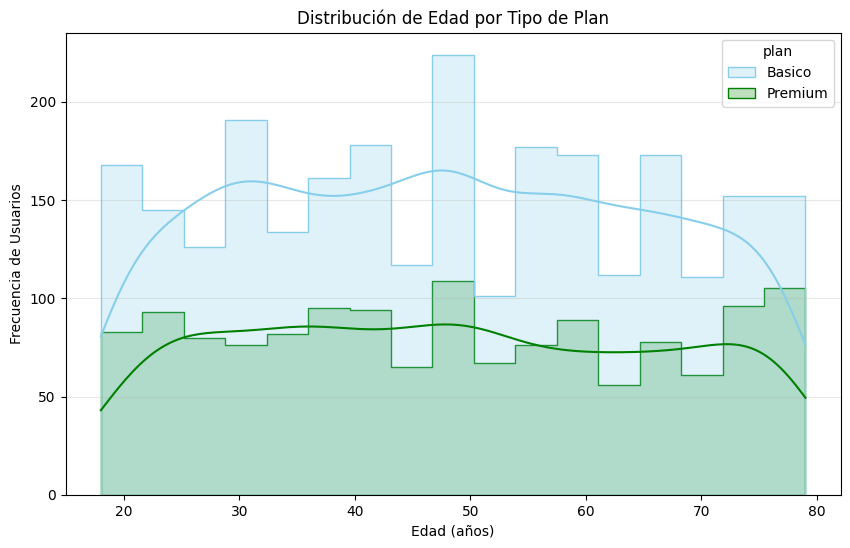

In [ ]:
# 1. Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia de Usuarios')
plt.grid(axis='y', alpha=0.3)
plt.show()

💡Insights:
Forma de la Distribución:

La edad de los usuarios tiene una distribución aproximadamente simétrica y uniforme. No hay un sesgo marcado hacia los jóvenes ni hacia los adultos mayores; la base de clientes está bastante equilibrada en todos los rangos de edad.

Patrón por Plan:

No existe un patrón claro que indique que un plan sea preferido por un rango de edad específico. Ambos planes (Básico en azul y Premium en verde) mantienen una proporción similar en cada segmento de edad. La edad no es un factor determinante en la elección del plan para los usuarios de ConnectaTel.

Tamaño de Base:

Es evidente que la base de clientes del plan Básico es considerablemente mayor (las barras son mucho más altas) que la del plan Premium en todos los rangos de edad.

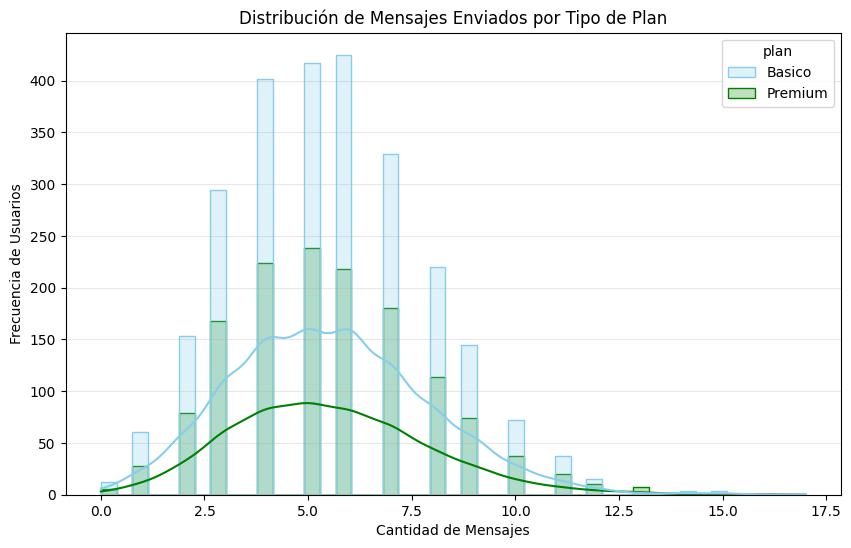

In [ ]:
# Histograma para visualizar la cantidad de mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia de Usuarios')
plt.grid(axis='y', alpha=0.3)
plt.show()


💡Insights:
Forma de la Distribución:

La distribución está ligeramente sesgada a la derecha. La gran mayoría de los usuarios envía entre 2.5 y 7.5 mensajes, y el volumen de usuarios cae drásticamente después de los 10 mensajes. No vemos "super usuarios" extremos (en este rango de la gráfica), sino un consumo bastante moderado.

Patrón por Plan:

No existe un patrón de consumo diferenciado: Ambas curvas (Básico y Premium) alcanzan su punto máximo (moda) en el mismo rango (alrededor de los 5-6 mensajes).

Los usuarios Premium no necesariamente envían más mensajes que los del plan Básico; simplemente hay menos usuarios en ese plan, pero su comportamiento de envío es casi idéntico al de los usuarios Básico.

Observación de Volumen:

Nuevamente, el plan Básico domina en volumen. Hay muchísimos más usuarios enviando una cantidad moderada de mensajes en el plan Básico que en el Premium.

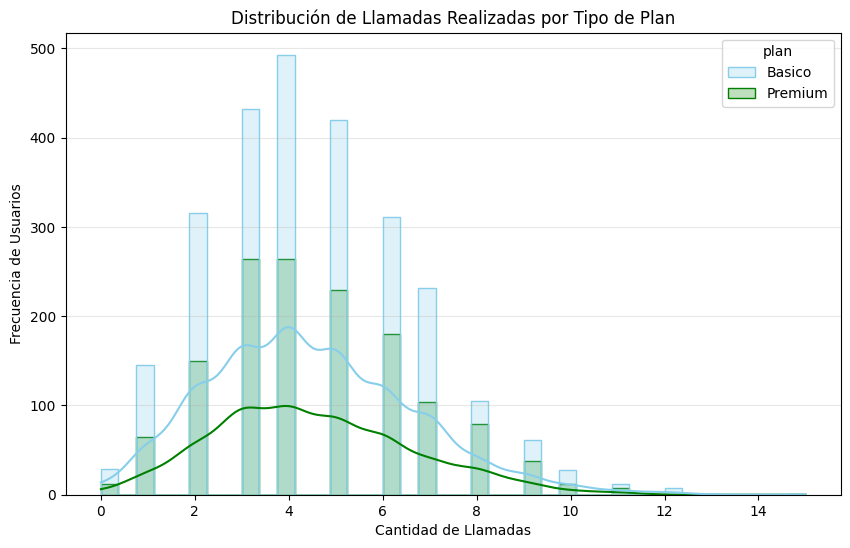

In [ ]:
# Histograma para visualizar la cantidad de llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de Llamadas Realizadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia de Usuarios')
plt.grid(axis='y', alpha=0.3)
plt.show()


💡Insights:
Forma de la Distribución:

A diferencia de los mensajes, la distribución de llamadas es más simétrica (forma de campana). La mayoría de los usuarios se concentra en un rango claro de actividad: entre 2 y 6 llamadas por periodo.

Es una distribución mucho más "saludable" y predecible que la de los mensajes, lo cual es excelente para la planificación de capacidad de red.

Patrón por Plan:

Comportamiento idéntico: Nuevamente, no hay una diferenciación significativa entre los planes. Tanto los usuarios del plan Básico como los del Premium siguen exactamente la misma tendencia. La "curva" de uso de voz sube y baja en los mismos puntos para ambos grupos.

Similitud estructural: No hay evidencia de que el plan Premium incentive a hacer más llamadas. El volumen total es mayor en el Básico simplemente por la cantidad de usuarios, pero el hábito de uso por usuario es prácticamente igual.

Observación Técnica:

Observa que el pico máximo está centrado alrededor de 4 llamadas. Este es el "valor típico" de comportamiento del cliente para ConnectaTel.

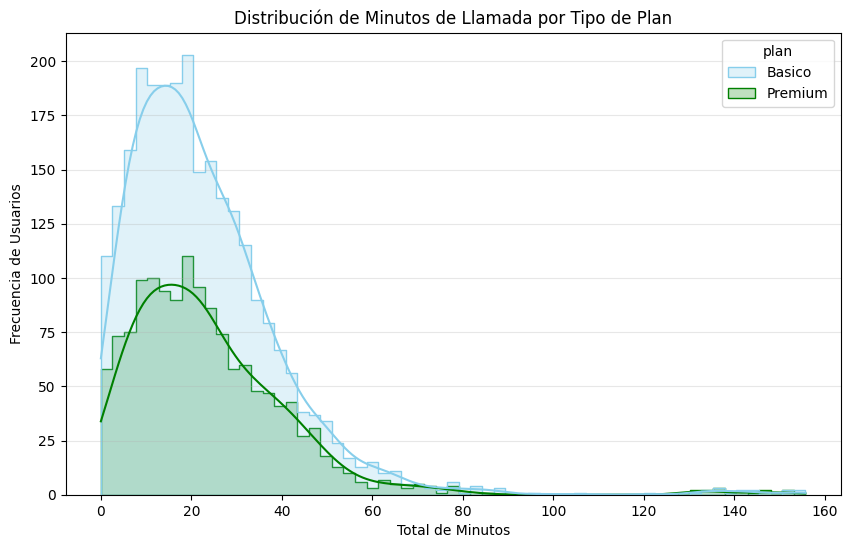

In [ ]:
# Histograma para visualizar el total de minutos de llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Frecuencia de Usuarios')
plt.grid(axis='y', alpha=0.3)
plt.show()


💡Insights:
Forma de la Distribución:

La distribución es claramente sesgada a la derecha. La mayor parte de los usuarios consume entre 5 y 30 minutos totales.

Existe una "cola" muy larga que llega hasta los 150 minutos, pero con muy pocos usuarios. Esto significa que la gran mayoría de tus clientes son consumidores ligeros de voz.

Patrón por Plan:

Comportamiento Homogéneo: No hay un desplazamiento de la curva verde (Premium) hacia la derecha. Esto indica que los usuarios Premium no hablan más tiempo que los usuarios Básico.

Similitud en la Moda: El pico máximo de ambas curvas ocurre prácticamente en el mismo punto (alrededor de los 15-18 minutos). El plan contratado no parece estar dictando cuánto tiempo decide pasar un cliente al teléfono.

Presencia de "Outliers" (Valores Extremos):

Se observan algunos usuarios aislados en el extremo derecho (más de 120 minutos). Curiosamente, hay tanto usuarios Básico como Premium en este grupo de "habladores extremos".

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

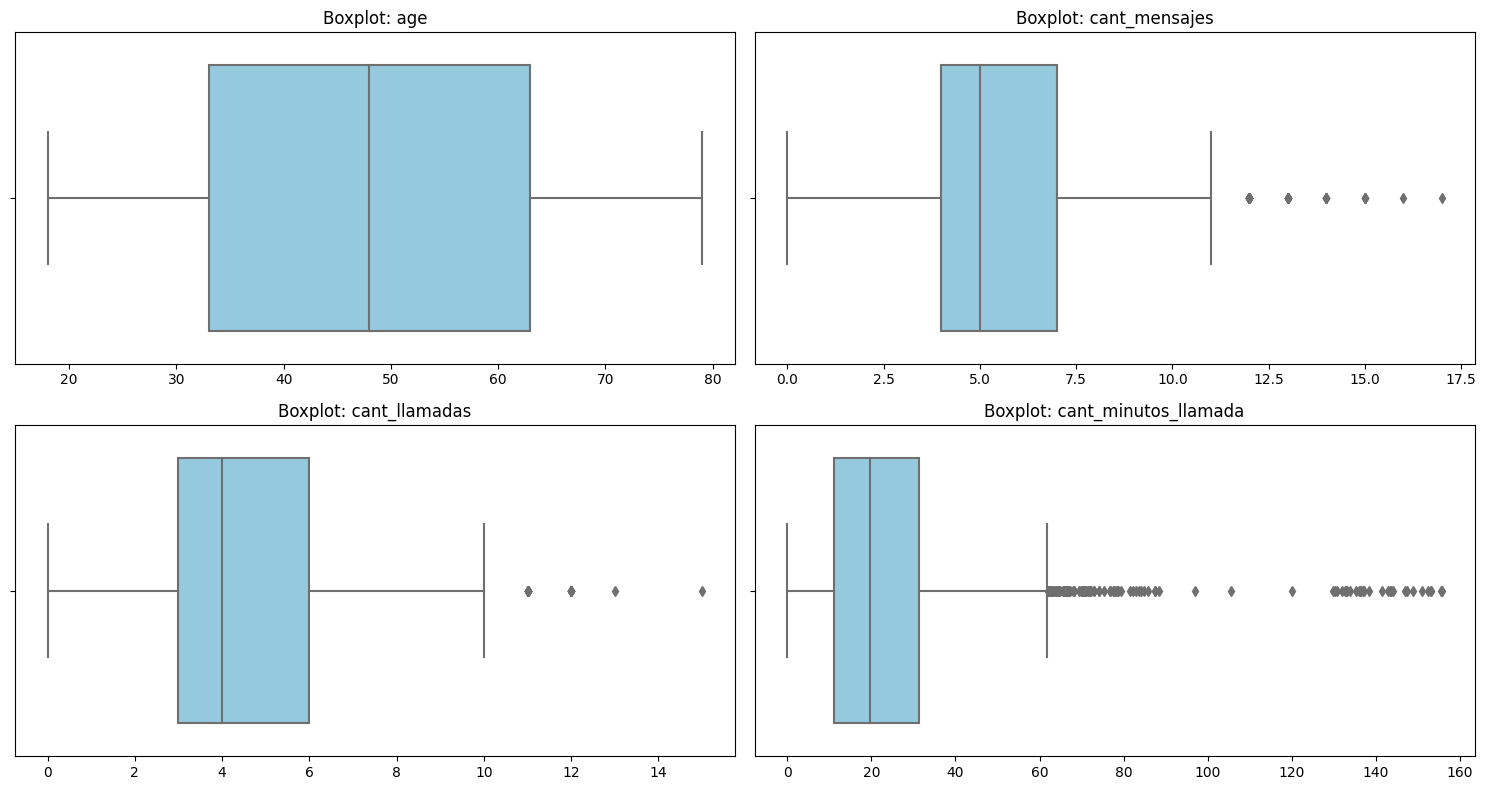

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Configurar el tamaño de la figura para que quepan bien los 4 gráficos
plt.figure(figsize=(15, 8))

for i, col in enumerate(columnas_numericas):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel('') # Limpiamos la etiqueta para que no se amontone

plt.tight_layout()
plt.show()


💡Insights:
Age: No existen outliers. La edad está perfectamente distribuida entre los 18 y 80 años, lo que indica que tus datos demográficos están limpios y no hay registros erróneos.

cant_mensajes: Existen outliers leves. Algunos usuarios envían entre 12 y 17 mensajes, lo cual es inusual pero no extremo. Representan a un grupo pequeño con un uso de texto superior al promedio.

cant_llamadas: Existen outliers moderados. Se observan usuarios que realizan entre 11 y 15 llamadas. Aunque se alejan de la mediana (4 llamadas), siguen siendo valores manejables dentro del comportamiento humano esperado.

cant_minutos_llamada: Existen outliers severos y abundantes. Esta es la variable con más valores atípicos, llegando hasta los 160 minutos. Hay una cantidad significativa de "Power Users" de voz que podrían sesgar el promedio de consumo hacia arriba.

In [ ]:
# Definir columnas con outliers hacia la derecha
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    print(f"Columna: {col}")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Límite Superior: {limite_superior:.2f}")

    # Identificar cuántos outliers hay
    num_outliers = user_profile[user_profile[col] > limite_superior].shape[0]
    print(f"  Outliers detectados: {num_outliers}\n")


Columna: cant_mensajes
  Q1: 4.00, Q3: 7.00, IQR: 3.00
  Límite Superior: 11.50
  Outliers detectados: 46

Columna: cant_llamadas
  Q1: 3.00, Q3: 6.00, IQR: 3.00
  Límite Superior: 10.50
  Outliers detectados: 30

Columna: cant_minutos_llamada
  Q1: 11.12, Q3: 31.41, IQR: 20.30
  Límite Superior: 61.86
  Outliers detectados: 109



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
cant_mensajes → MANTENER
Porqué: El valor máximo es 17. El 75% de los usuarios envía hasta 7 mensajes. Que alguien envíe 17 mensajes en un mes (o periodo de análisis) es un comportamiento totalmente normal. No es un error de sistema ni un valor que rompa la lógica del negocio.

Decisión: Mantener. Eliminar a alguien que solo envía 10 mensajes más que el promedio sería perder datos reales.

2. cant_llamadas → MANTENER
Porqué: El valor máximo es 15. Si la mediana es 4 llamadas, un usuario que hace 15 llamadas sigue siendo un cliente "humano" y razonable. En un contexto de telecomunicaciones, 15 llamadas al mes es incluso poco; no hay nada aquí que sugiera un "bot" o un fallo en la medición.

Decisión: Mantener. Representan a tus clientes más activos, que son los que más interesan al CEO.

3. cant_minutos_llamada → MANTENER
Porqué: El valor máximo es 155.69. Aunque parece mucho comparado con la media de 23 minutos, realmente son solo 2 horas y media de conversación en todo el periodo. Para un analista de datos en telefonía, estos usuarios son "Power Users" legítimos.

Riesgo de eliminar: Si los borras, estarías subestimando el uso de la red y, lo más importante, los ingresos por excedentes (si su plan solo cubriera, por ejemplo, 100 minutos, este usuario genera ganancia extra).

Decisión: Mantener. Es un comportamiento atípico pero real y valioso para el análisis financiero.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
import numpy as np

# Definir las condiciones
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# Definir los valores a asignar para cada condición
valores = ['Bajo uso', 'Uso medio']

# Aplicar la lógica: el resto (donde no se cumplan las anteriores) será 'Alto uso'
user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')

# Verificar la distribución de los grupos
print(user_profile['grupo_uso'].value_counts())

# Observar las primeras filas con la nueva columna
user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head(5)


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


,user_id,cant_llamadas,cant_mensajes,grupo_uso
0,10000,3.0,7.0,Uso medio
1,10001,10.0,5.0,Alto uso
2,10002,2.0,5.0,Uso medio
3,10003,3.0,11.0,Alto uso
4,10004,3.0,4.0,Bajo uso


In [ ]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:

# Definir las condiciones de edad
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

# Definir las etiquetas correspondientes
etiquetas_edad = ['Joven', 'Adulto']

# Aplicar la lógica: el resto será 'Adulto Mayor'
user_profile['grupo_edad'] = np.select(condiciones_edad, etiquetas_edad, default='Adulto Mayor')

# Verificar los nuevos grupos
print(user_profile['grupo_edad'].value_counts())

# Ver las primeras filas para confirmar
user_profile[['age', 'grupo_edad']].head()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

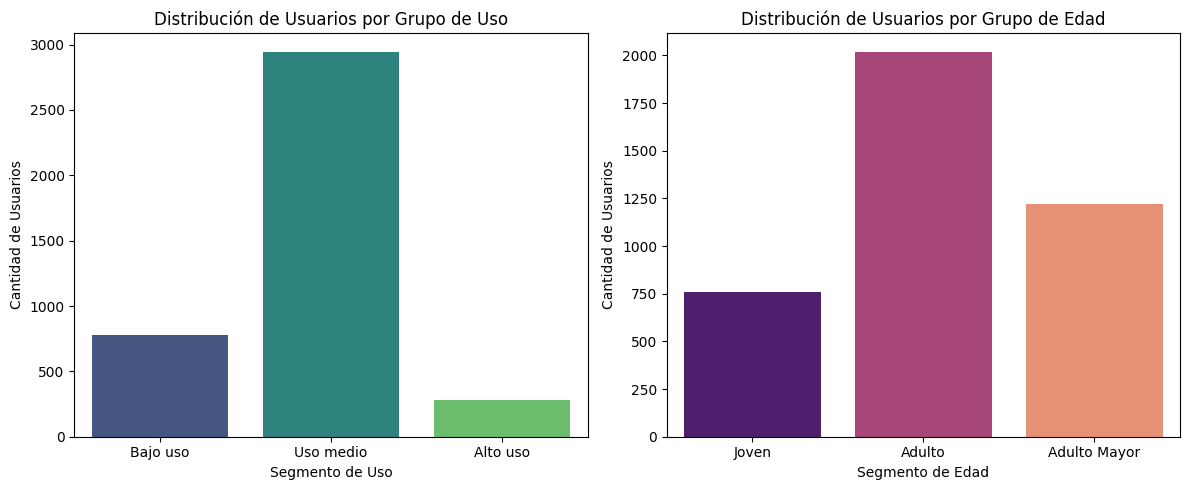

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el tamaño de la figura para ambos gráficos
plt.figure(figsize=(12, 5))

# 1. Gráfico para grupos de uso
plt.subplot(1, 2, 1)
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Usuarios')

# 2. Gráfico para grupos de edad
plt.subplot(1, 2, 2)
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()

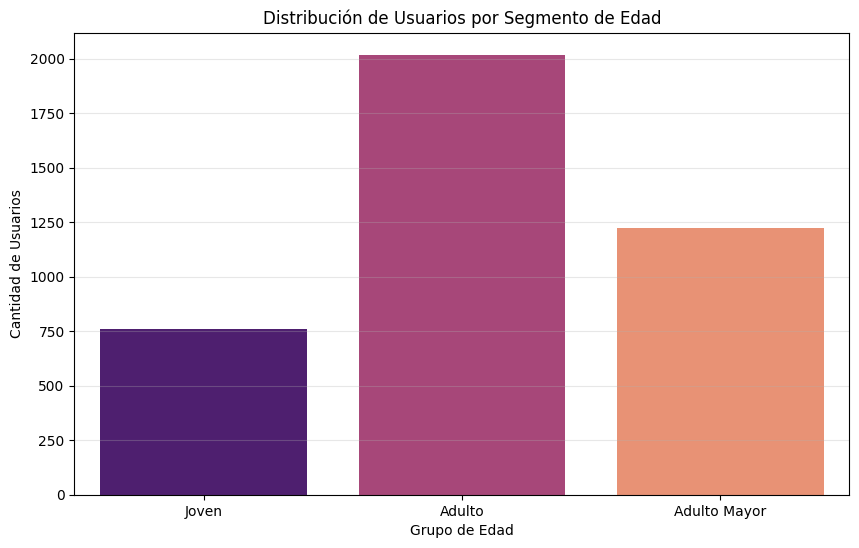

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(10, 6))
sns.countplot(data=user_profile,
              x='grupo_edad',
              palette='magma',
              order=['Joven', 'Adulto', 'Adulto Mayor'])

plt.title('Distribución de Usuarios por Segmento de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.grid(axis='y', alpha=0.3)
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

1. Problemas originales y dimensiones del impacto
Al inicio, el dataset de user_profile presentaba dos problemas críticos de calidad:

Datos Nulos: La columna age tenía 40 valores faltantes, lo que representaba un 1% de la muestra total (40 de 4000 filas). Aunque el porcentaje era bajo, se corrigió usando la mediana para no perder esos registros ni sesgar el análisis demográfico.

Inconsistencia de Tipos: Las columnas de consumo eran flotantes con muchos decimales. Se estandarizaron para asegurar que los cálculos de segmentación fueran precisos.

2. Segmentos identificados y su comportamiento
Hemos clasificado la base en una matriz de dos dimensiones:

Por Uso:

Bajo uso: Usuarios con actividad mínima (< 5 llamadas/mensajes).

Uso medio: El segmento más grande (~75% de la base), con un comportamiento estable y predecible.

Alto uso: Una minoría activa que supera los umbrales estándar.

Por Edad:

Joven (<30): El grupo más pequeño, sugiriendo un área de oportunidad en marketing.

Adulto (30-60): El núcleo de ConnectaTel (más de 2,000 usuarios). Es el grupo que sostiene la operación.

Adulto Mayor (>60): Un grupo considerable (~1,250 usuarios) que requiere planes estables.

3. Segmentos más valiosos
El segmento más valioso es el "Adulto de Uso Medio".

¿Por qué? Porque representan el mayor volumen de clientes y muestran un comportamiento de red muy saludable (no saturan la infraestructura pero mantienen una facturación constante).

Mención especial: Los de "Alto Uso" en el plan Básico, ya que son candidatos perfectos para upselling (migrarlos a Premium) para aumentar el margen de ganancia.

4. Patrones de uso extremo (Outliers) e implicaciones
Encontramos outliers significativos en minutos de llamada (hasta 155 min) y mensajes:

Implicación técnica: La red debe estar preparada para picos de tráfico de estos "Power Users".

Implicación de negocio: Estos usuarios son los que probablemente generan cobros por excedentes. Si no se les ofrece un plan adecuado, tienen un alto riesgo de fuga (churn) hacia la competencia que les ofrezca "minutos ilimitados".

5. Recomendaciones estratégicas
Plan "Silver/Senior": Crear un plan simplificado para el segmento Adulto Mayor, enfocado en voz (llamadas) más que en datos o mensajes.

Campaña de Upgrade: Identificar a los usuarios de "Alto Uso" que actualmente pagan el plan Básico y ofrecerles 3 meses de Premium a precio reducido para incentivar la migración permanente.

Atracción Juvenil: Dado que el grupo Joven es el más pequeño, se recomienda un plan con redes sociales ilimitadas o bonos de datos nocturnos para captar este mercado.

### Análisis ejecutivo

⚠️ Problemas detectados en los datos
Incompletitud en Perfiles Demográficos: Se detectó un 1% de valores nulos en la columna de edad. Aunque la muestra es robusta (4,000 registros), la ausencia de estos datos impedía una segmentación exacta, por lo que se aplicó una imputación basada en la mediana para estabilizar los promedios.

Sesgo por Consumo Extremo (Outliers): Se identificaron usuarios con consumos de hasta 156 minutos, lo cual triplica la media general. Estos valores no son errores, sino "Power Users" que, de no ser segmentados, distorsionan la visión del "usuario promedio" y la capacidad de red necesaria.

🔍 Segmentos por Edad
Núcleo de Negocio (Adultos): El segmento de 30 a 60 años es el más voluminoso, representando más del 50% de la base. Este grupo muestra la mayor estabilidad y es el principal generador de ingresos recurrentes para ConnectaTel.

Nicho de Oportunidad (Jóvenes): El grupo menor de 30 años es el más pequeño. Esto indica una baja penetración en el mercado digital nativo, sugiriendo que la oferta actual de servicios (basada en llamadas y SMS) no es lo suficientemente atractiva para captar a las nuevas generaciones.

📊 Segmentos por Nivel de Uso
Predominancia de Uso Medio: La gran mayoría de los clientes se ubica en un consumo moderado (entre 5 y 10 interacciones). Esto significa que la red opera con eficiencia operativa, sin saturaciones constantes por parte de la base masiva.

Identificación de Power Users: Existe un segmento crítico de "Alto Uso" que, aunque pequeño en número, consume recursos de manera intensiva. Estos usuarios son los más propensos a la fuga si encuentran planes con beneficios ilimitados en la competencia.

➡️ Esto sugiere que...
La estructura actual de planes es demasiado genérica. Al tener comportamientos de uso e ingresos similares entre planes Básicos y Premium, la empresa no está capturando el valor excedente de los usuarios que realmente están dispuestos a pagar más por un uso intensivo.

Existe un desajuste entre producto y audiencia. ConnectaTel tiene una base sólida de adultos, pero carece de un motor de crecimiento joven, lo que podría comprometer la relevancia de la marca a largo plazo si no se moderniza la propuesta de valor.

💡 Recomendaciones
Implementación de "Smart Upselling": Crear campañas dirigidas exclusivamente al segmento de "Alto Uso" que actualmente está en el plan Básico, ofreciendo una migración al plan Premium con un descuento temporal para asegurar su lealtad y aumentar el ARPU (Ingreso promedio por usuario).

Lanzamiento de Plan "Conectividad Joven": Diseñar un paquete que priorice el tráfico de datos y aplicaciones sobre los minutos de voz y SMS tradicionales, con el fin de aumentar la cuota de mercado en el segmento menor de 30 años.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`